## importing necessary packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
print(df["TotalCharges"])
print("TotalCharges dtype:", df["TotalCharges"].dtype)
print("Rows with whitespace in TotalCharges:", (df["TotalCharges"].str.strip() == "").sum())

0         29.85
1        1889.5
2        108.15
3       1840.75
4        151.65
         ...   
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, Length: 7043, dtype: str
TotalCharges dtype: str
Rows with whitespace in TotalCharges: 11


In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df['TotalCharges'] = df["TotalCharges"].fillna(0)

In [6]:
print("Before conversion: " + str(df['Churn'].dtype))
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("After conversion: " + str(df['Churn'].dtype))

Before conversion: str
After conversion: int64


In [7]:
print(f"\nRemaining nulls:\n{df.isnull().sum()[df.isnull().sum() > 0]}")


Remaining nulls:
Series([], dtype: int64)


In [8]:
churn_counts = df['Churn'].value_counts()
print(churn_counts)

Churn
0    5174
1    1869
Name: count, dtype: int64


### Customer Churn Distribution

The churn distribution shows that most customers were retained, while a smaller portion churned. This indicates a moderate class imbalance, with retention clearly outweighing churn. Even so, the number of churned customers is still large enough to make churn an important area for further analysis.

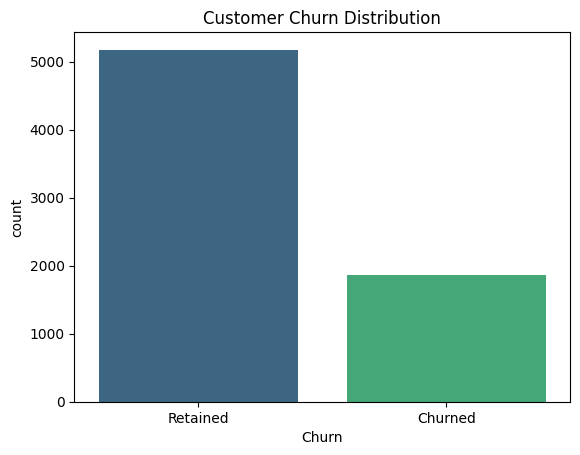

In [9]:
churn_plot = df[['Churn']].copy()
churn_plot['Churn'] = df['Churn'].map({0: 'Retained', 1: 'Churned'})
sns.countplot(x='Churn', 
              hue ='Churn',
              data = churn_plot, 
              palette='viridis'
)
plt.title('Customer Churn Distribution')    
plt.show()

### Churn Rate by Tenure Bucket

Churn is highest among customers with 0–12 months of tenure and steadily decreases as tenure increases. This suggests that newer customers are significantly more likely to leave, while long-term customers are more likely to stay. Early retention efforts may have the greatest impact on reducing overall churn.

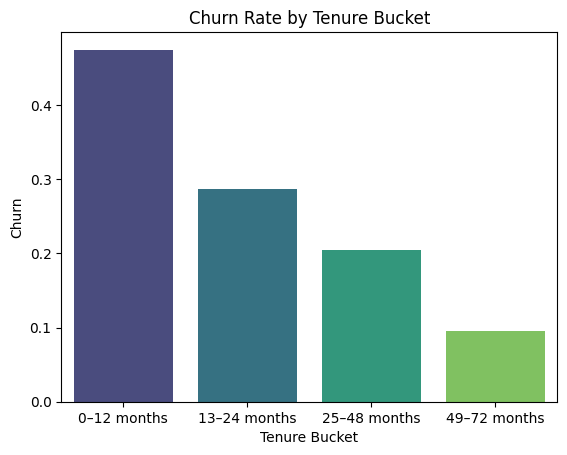

In [10]:
df["tenure_bucket"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0–12 months", "13–24 months", "25–48 months", "49–72 months"],
    include_lowest=True
)

tenure_churn_plot = df.groupby("tenure_bucket")["Churn"].mean().reset_index()
sns.barplot(
    x="tenure_bucket",
    y="Churn",
    hue="tenure_bucket",
    data=tenure_churn_plot,
    palette='viridis',
    dodge = False,
    legend=False
)

plt.title("Churn Rate by Tenure Bucket")
plt.xlabel("Tenure Bucket")
plt.show()

### Churn Rate by Internet Service Type

Customers with fiber optic service have the highest churn rate, followed by DSL, while those with no internet service churn the least. This suggests that higher-tier services may be associated with greater dissatisfaction or expectations, making them a key area for further investigation.

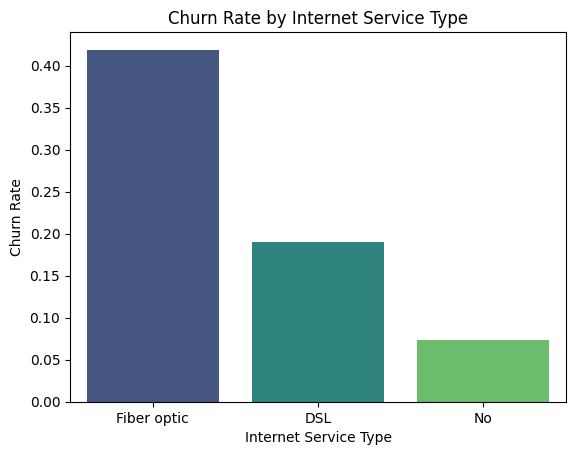

In [11]:
internet_churn_plot = df.groupby('InternetService')['Churn'].mean().sort_values(ascending = False)
sns.barplot(x=internet_churn_plot.index, 
            y=internet_churn_plot.values, 
            hue = internet_churn_plot.index,
            dodge = False,
            palette='viridis')
plt.title("Churn Rate by Internet Service Type")
plt.xlabel("Internet Service Type")
plt.ylabel("Churn Rate")
plt.show()

### Churn Rate by Payment Method

Customers using electronic checks have the highest churn rate, while those using automatic payment methods (bank transfer or credit card) have the lowest. This suggests that customers on auto-pay are more stable, while electronic check users may be less committed or more likely to leave.

Text(0, 0.5, 'Churn Rate')

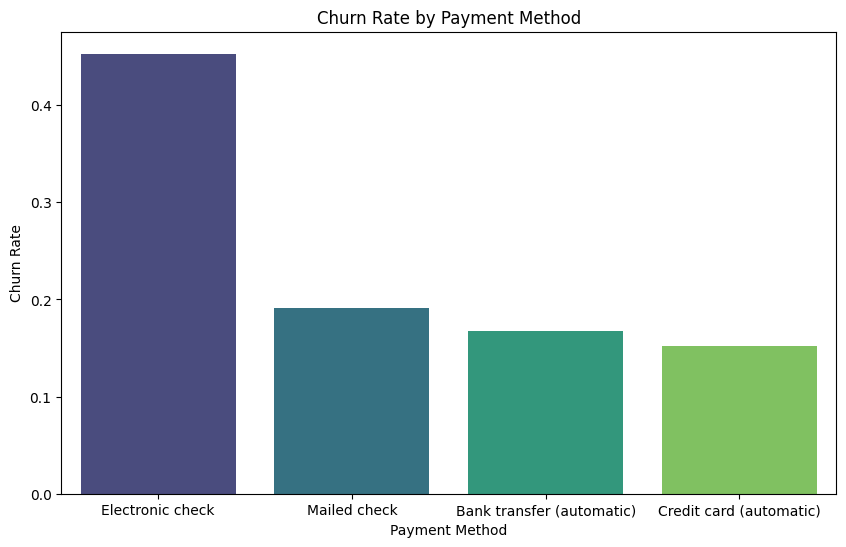

In [12]:
payment_churn_plot = df.groupby("PaymentMethod")["Churn"].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=payment_churn_plot.index, 
            y=payment_churn_plot.values, 
            hue = payment_churn_plot.index,
            dodge = False,
            palette='viridis')
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate")


### Monthly Charges vs Churn

Churned customers have higher monthly charges on average (~$74) compared to retained customers (~$61). This suggests that higher-paying customers are more likely to churn, indicating potential pricing sensitivity or dissatisfaction among higher-value users.

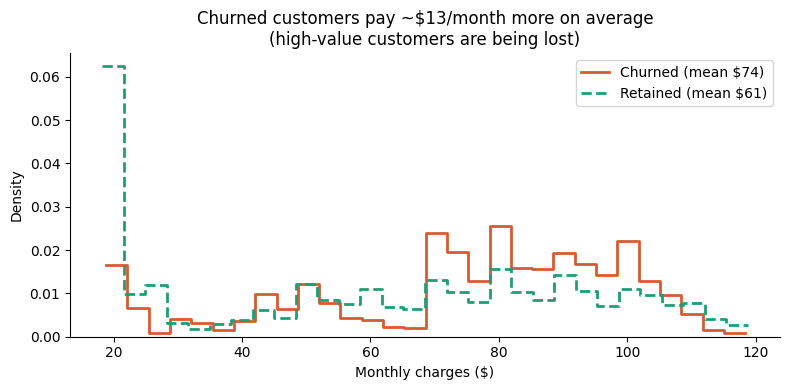

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))

churned = df[df["Churn"] == 1]["MonthlyCharges"]
retained = df[df["Churn"] == 0]["MonthlyCharges"]

sns.histplot(
    churned,
    bins=30,
    stat="density",
    element="step",
    fill=False,
    ax=ax,
    label=f"Churned (mean ${churned.mean():.0f})",
    color="#D85A30",
    linewidth=2
)

sns.histplot(
    retained,
    bins=30,
    stat="density",
    element="step",
    fill=False,
    ax=ax,
    label=f"Retained (mean ${retained.mean():.0f})",
    color="#1D9E75",
    linestyle="--",
    linewidth=2
)

ax.set(
    xlabel="Monthly charges ($)",
    ylabel="Density",
    title="Churned customers pay ~$13/month more on average\n(high-value customers are being lost)"
)

ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

### Tenure Distribution by Churn

Churned customers tend to have much shorter tenures (~18 months on average) compared to retained customers (~38 months). This reinforces that churn risk is highest early in the customer lifecycle, highlighting the importance of improving retention during the first year.

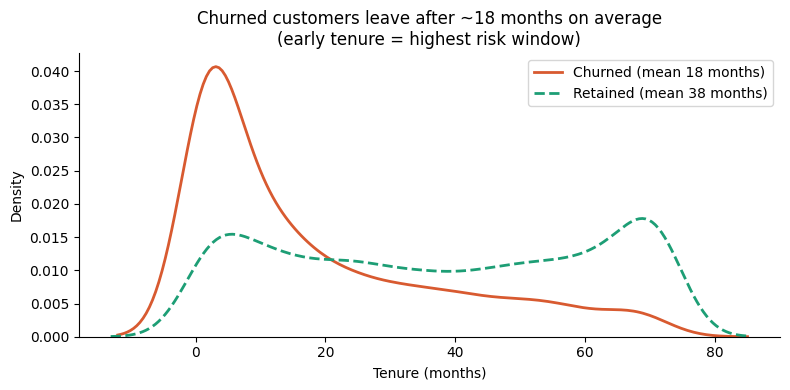

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))

for label, color, ls, name in [
    (1, "#D85A30", "-", "Churned"),
    (0, "#1D9E75", "--", "Retained")
]:
    subset = df[df["Churn"] == label]["tenure"]
    
    sns.kdeplot(
        subset,
        ax=ax,
        label=f"{name} (mean {subset.mean():.0f} months)",
        color=color,
        linestyle=ls,
        linewidth=2
    )

ax.set(
    xlabel="Tenure (months)",
    ylabel="Density",
    title="Churned customers leave after ~18 months on average\n(early tenure = highest risk window)"
)

ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

### Correlation Matrix (Numerical Features)

Tenure shows a moderate negative correlation with churn, indicating that longer-tenured customers are less likely to leave. MonthlyCharges has a weak positive correlation with churn, suggesting higher costs may slightly increase churn risk. TotalCharges is strongly correlated with tenure, as expected, but has a weak negative relationship with churn.

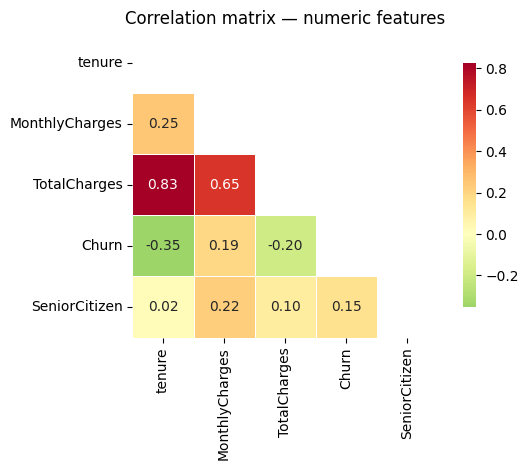

In [15]:
corr = df[["tenure", "MonthlyCharges", "TotalCharges", "Churn", "SeniorCitizen"]].corr()

sns.heatmap(
    corr,
    mask=np.triu(np.ones_like(corr, dtype=bool)),
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation matrix — numeric features")
plt.tight_layout()
plt.show()

In [16]:
df.to_parquet("../data/processed/telco_clean.parquet", index=False)
print("Saved: data/processed/telco_clean.parquet")

Saved: data/processed/telco_clean.parquet


In [17]:
print('=== CLASS BALANCE ===')
print(df['Churn'].value_counts())
print(f'Churn rate: {df["Churn"].mean()*100:.1f}%')

print('\n=== CHURN RATE BY CONTRACT ===')
print(df.groupby('Contract')['Churn'].mean().mul(100).round(1).astype(str) + '%')

print('\n=== CHURN RATE BY TENURE BUCKET ===')
print(df.groupby('tenure_bucket', observed=True)['Churn'].mean().mul(100).round(1).astype(str) + '%')

print('\n=== AVG MONTHLY CHARGES: CHURNED VS RETAINED ===')
print(df.groupby(df['Churn'].map({1:'Churned',0:'Retained'}))['MonthlyCharges'].mean().round(2))

print('\n=== AVG TENURE: CHURNED VS RETAINED ===')
print(df.groupby(df['Churn'].map({1:'Churned',0:'Retained'}))['tenure'].mean().round(1))

=== CLASS BALANCE ===
Churn
0    5174
1    1869
Name: count, dtype: int64
Churn rate: 26.5%

=== CHURN RATE BY CONTRACT ===
Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: Churn, dtype: str

=== CHURN RATE BY TENURE BUCKET ===
tenure_bucket
0–12 months     47.4%
13–24 months    28.7%
25–48 months    20.4%
49–72 months     9.5%
Name: Churn, dtype: str

=== AVG MONTHLY CHARGES: CHURNED VS RETAINED ===
Churn
Churned     74.44
Retained    61.27
Name: MonthlyCharges, dtype: float64

=== AVG TENURE: CHURNED VS RETAINED ===
Churn
Churned     18.0
Retained    37.6
Name: tenure, dtype: float64


---
## EDA Summary

This notebook explored 7,043 Telco customer records across 21 features to understand what drives churn (26.5% of customers). Below are the key findings and their business implications.

---

### Data quality

| Issue | Detail | Fix applied |
|-------|--------|-------------|
| `TotalCharges` stored as string | Blank strings (not `NaN`) for 11 new customers with `tenure=0` | `pd.to_numeric(errors='coerce')` → `fillna(0)` |
| `Churn` stored as Yes/No strings | Not usable for modeling | Mapped to `1`/`0` |

The `TotalCharges` bug is a realistic data quality issue: blank strings are invisible to `.isnull()` and would silently corrupt any numeric operation on the column.

---

### Key findings

| # | Finding | Signal strength |
|---|---------|----------------|
| 1 | **Class imbalance** — 26.5% churn vs 73.5% retained | Moderate — requires SMOTE or `class_weight='balanced'` in modeling |
| 2 | **Contract type** is the dominant predictor — month-to-month customers churn at 42.7% vs 2.8% for two-year contracts | Very strong |
| 3 | **Early tenure is the highest-risk window** — 47.7% of customers in their first year churn, falling to 9.5% after 4 years | Very strong |
| 4 | **Fiber optic anomaly** — fiber customers churn at 41.9% vs 19% for DSL despite being a premium service | Strong — possible pricing or quality issue |
| 5 | **Electronic check = disengagement proxy** — 45.3% churn vs ~15–17% for auto-pay methods | Strong — likely correlated with month-to-month contracts |
| 6 | **Churned customers are higher value** — avg monthly charge $74 vs $61 for retained | Important for revenue impact framing |
| 7 | **Tenure negatively correlated with churn** (r = -0.35) — strongest numeric correlation in the dataset | Moderate |

---

### Business implications

- The highest-leverage retention intervention is **locking in month-to-month customers on longer contracts early** — the churn rate difference is 15x.
- Customers in their **first 12 months** are the most critical window for retention campaigns.
- The **fiber optic churn rate warrants investigation** — it is disproportionately high for a premium product and may indicate pricing dissatisfaction or service quality issues.
- Because churned customers have **higher monthly charges**, the revenue at risk is greater than the raw churn percentage implies. A 26.5% churn rate likely represents a disproportionately high share of monthly recurring revenue.

---

### Next steps

- **`feature_engineering.ipynb`** — build retention-related features: charge-to-tenure ratio, multi-service flag, contract risk score, engagement tier
- **`modeling.ipynb`** — train logistic regression baseline and XGBoost, apply SMOTE, tune classification threshold, compute SHAP values
- **`app.py`** — Streamlit dashboard surfacing churn risk by segment, top drivers, and customer-level intervention table